In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/faizanhaider01/hours-attendence/student_scores.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/faizanhaider01/hours-attendence/student_scores.csv')

In [4]:
df.sample(4)

,study_hours,attendance_pct,exam_score
89,5.2,62.1,61.4
36,3.7,75.9,53.7
17,5.7,59.3,58.3
79,2.0,56.9,47.8


In [5]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=2)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_saled = scale.transform(X_test)

In [10]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [11]:
model = Sequential()
model.add(Dense(10,activation = 'relu',input_dim =2))
model.add(Dense(4,activation = 'linear'))
model.add(Dense(1,activation = 'linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-31 12:05:50.465898: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss = 'mean_squared_error', metrics=[tensorflow.keras.metrics.R2Score()])

In [25]:
history = model.fit(X_train_scaled,y_train,epochs=50,batch_size=1,validation_split=0.2)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 55.8372 - r2_score: 0.7585 - val_loss: 38.2189 - val_r2_score: 0.7980
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.7465 - r2_score: 0.7589 - val_loss: 39.0822 - val_r2_score: 0.7934
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.9116 - r2_score: 0.7625 - val_loss: 37.9151 - val_r2_score: 0.7996
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.4087 - r2_score: 0.7604 - val_loss: 38.4302 - val_r2_score: 0.7968
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.5386 - r2_score: 0.7598 - val_loss: 38.1088 - val_r2_score: 0.7985
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.2762 - r2_score: 0.7610 - val_loss: 38.5871 - val_r2_score: 0.7960
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54.5181 - r2_score: 0.7642 - val_loss: 37.4793 - val_r2_score: 0.8019
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 55.4441 - r2_score: 0.7602 - val_loss: 38.4439

# BATCH GD:

In [15]:
model.compile(loss = 'mean_squared_error', metrics=[tensorflow.keras.metrics.R2Score()])

In [27]:
historys = model.fit(X_train_scaled,y_train,epochs=50,batch_size=64,validation_split=0.2)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 52.6433 - r2_score: 0.7723 - val_loss: 40.8441 - val_r2_score: 0.7841
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 52.6389 - r2_score: 0.7724 - val_loss: 40.8451 - val_r2_score: 0.7841
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 52.6344 - r2_score: 0.7724 - val_loss: 40.8459 - val_r2_score: 0.7841
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 52.6299 - r2_score: 0.7724 - val_loss: 40.8466 - val_r2_score: 0.7841
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 52.6252 - r2_score: 0.7724 - val_loss: 40.8471 - val_r2_score: 0.7841
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 52.6204 - r2_score: 0.7724 - val_loss: 40.8475 - val_r2_score: 0.7841
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 52.6156 - r2_score: 0.7725 - val_loss: 40.8476 - val_r2_score: 0.7841
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 52.6108 - r2_score: 0.7725 - val_loss: 40.8476 - val_r

# Mini Batch Gd:

In [17]:
model.compile(loss = 'mean_squared_error', metrics=[tensorflow.keras.metrics.R2Score()])

In [29]:
historys_ = model.fit(X_train_scaled,y_train,epochs=50,batch_size=12,validation_split=0.2)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 53.1328 - r2_score: 0.7702 - val_loss: 40.1512 - val_r2_score: 0.7877
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 52.5565 - r2_score: 0.7727 - val_loss: 40.0737 - val_r2_score: 0.7882
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 52.7205 - r2_score: 0.7720 - val_loss: 39.7505 - val_r2_score: 0.7899
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.6429 - r2_score: 0.7723 - val_loss: 39.9924 - val_r2_score: 0.7886
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.6334 - r2_score: 0.7724 - val_loss: 40.4480 - val_r2_score: 0.7862
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 52.7348 - r2_score: 0.7719 - val_loss: 40.0966 - val_r2_score: 0.7880
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 52.6540 - r2_score: 0.7723 - val_loss: 39.7038 - val_r2_score: 0.7901
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 53.0592 - r2_score: 0.7705 - val_loss: 40.6670 - val_r

In [19]:
import matplotlib.pyplot as plt

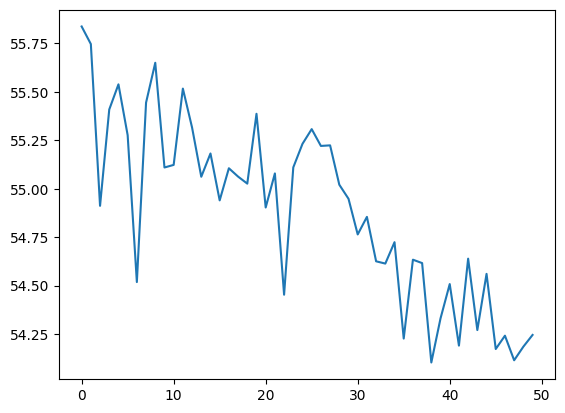

In [26]:
plt.plot(history.history['loss'])

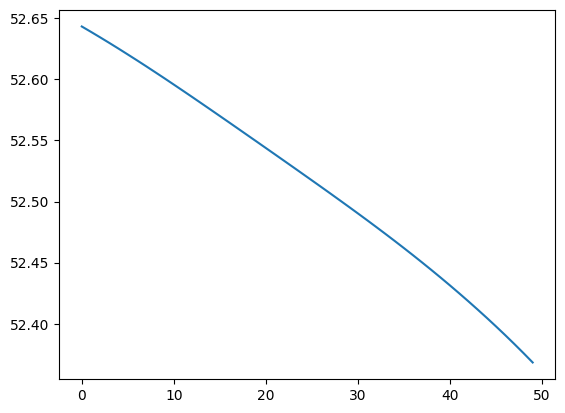

In [28]:
plt.plot(historys.history['loss'])

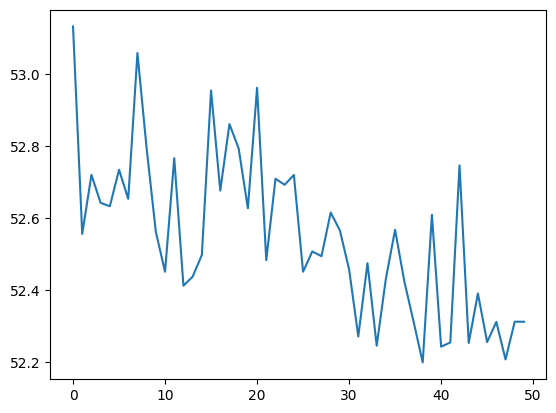

In [30]:
plt.plot(historys_.history['loss'])